# ⭐ Day 10: NumPy Arrays & Vectorization
Speed Up Your AI & ML Code | Step-by-Step Tutorial with Examples & Exercises

*Day 10 of 369-day Python & AI Learning Path* 💡

## Introduction

Welcome to Day 10 of your Python & AI Learning Path! Today we're diving into one of the most fundamental libraries in the Python data science ecosystem: **NumPy**. If you're serious about AI and machine learning, mastering NumPy isn't optional—it's essential.

NumPy (Numerical Python) serves as the foundation upon which almost every major data science library is built. Whether you're using pandas for data manipulation, scikit-learn for machine learning, or TensorFlow and PyTorch for deep learning, they all rely on NumPy arrays under the hood. Understanding NumPy means understanding how data flows through your AI pipelines.

The secret sauce that makes NumPy so powerful is **vectorization**—the ability to perform operations on entire arrays at once rather than looping through elements one by one. This isn't just syntactic sugar; it's a paradigm shift that can speed up your code by 10x, 100x, or even 1000x compared to pure Python loops. When you're training neural networks on millions of data points, these performance gains become absolutely critical.

Beyond speed, NumPy offers **memory efficiency** through contiguous memory storage and optimized C implementations, and **broadcasting**—a powerful mechanism that allows operations between arrays of different shapes without explicit replication. These features make NumPy indispensable for handling large datasets common in AI/ML workflows.

By the end of this tutorial, you'll not only know how to create and manipulate arrays, but you'll also understand the performance implications of your code choices—a skill that separates beginner data scientists from professional ML engineers.

## 📌 Table of Contents

1. [Creating NumPy Arrays](#creating-arrays)
2. [Array Attributes](#array-attributes)
3. [Indexing & Slicing](#indexing-slicing)
4. [Vectorization vs Python Loops](#vectorization)
5. [Mathematical Operations & Broadcasting](#math-ops)
6. [Universal Functions (ufuncs)](#ufuncs)
7. [Aggregation Functions](#aggregation)
8. [Boolean Indexing & Masking](#boolean-indexing)
9. [Reshaping & Transposing](#reshaping)
10. [Common AI/ML Patterns](#ml-patterns)
11. [🛠️ Hands-On Exercises](#exercises)
12. [Solutions](#solutions)

## 1. Creating NumPy Arrays {#creating-arrays}

NumPy provides multiple ways to create arrays. Here are the most common methods you'll use daily:

In [1]:
import numpy as np

# Creating arrays from Python lists
arr1 = np.array([1, 2, 3, 4, 5])
print(f"From list: {arr1}")

# 2D array (matrix)
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(f"2D array:\n{arr2d}")

# Arrays filled with zeros (common for initialization in ML)
zeros = np.zeros((3, 4))
print(f"Zeros:\n{zeros}")

# Arrays filled with ones
ones = np.ones((2, 3))
print(f"Ones:\n{ones}")

# Identity matrix (useful in linear algebra for ML)
identity = np.eye(3)
print(f"Identity matrix:\n{identity}")

# Evenly spaced values (arange)
arange_arr = np.arange(0, 10, 2)  # start, stop, step
print(f"Arange: {arange_arr}")

# Linearly spaced values (useful for plotting)
linspace_arr = np.linspace(0, 1, 5)  # 5 values from 0 to 1 inclusive
print(f"Linspace: {linspace_arr}")

# Random arrays (crucial for ML: weight initialization, data augmentation)
np.random.seed(42)  # For reproducibility
random_arr = np.random.rand(3, 3)  # Uniform [0, 1)
print(f"Random uniform:\n{random_arr}")

random_normal = np.random.randn(3, 3)  # Standard normal distribution
print(f"Random normal:\n{random_normal}")

random_int = np.random.randint(0, 10, size=(2, 3))  # Random integers
print(f"Random integers:\n{random_int}")

From list: [1 2 3 4 5]
2D array:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Zeros:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Ones:
[[1. 1. 1.]
 [1. 1. 1.]]
Identity matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Arange: [0 2 4 6 8]
Linspace: [0.   0.25 0.5  0.75 1.  ]
Random uniform:
[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]]
Random normal:
[[-0.58087813 -0.52516981 -0.57138017]
 [-0.92408284 -2.61254901  0.95036968]
 [ 0.81644508 -1.523876   -0.42804606]]
Random integers:
[[2 6 3]
 [8 2 4]]


## 2. Array Attributes {#array-attributes}

Understanding array properties is crucial for debugging shape mismatches in ML models:

In [2]:
arr = np.random.randn(3, 4, 5)  # 3D array

print(f"Array:\n{arr}")
print(f"\nShape (dimensions): {arr.shape}")  # (3, 4, 5)
print(f"Number of dimensions (ndim): {arr.ndim}")  # 3
print(f"Total elements (size): {arr.size}")  # 60
print(f"Data type (dtype): {arr.dtype}")  # float64
print(f"Item size (bytes): {arr.itemsize}")  # 8 bytes per element
print(f"Total memory (bytes): {arr.nbytes}")  # 480 bytes

# Common patterns in ML
# Shape is critical for neural networks: (batch_size, features) or (batch_size, height, width, channels)
batch_data = np.random.randn(32, 784)  # 32 samples, 784 features (e.g., flattened 28x28 images)
print(f"\nML batch shape: {batch_data.shape}")
print(f"Number of samples: {batch_data.shape[0]}")
print(f"Number of features: {batch_data.shape[1]}")

Array:
[[[-0.74240684 -1.15099358  0.37569802 -0.60063869 -0.29169375]
  [-0.60170661  1.85227818 -0.01349722 -1.05771093  0.82254491]
  [-1.22084365  0.2088636  -1.95967012 -1.32818605  0.19686124]
  [ 0.73846658  0.17136828 -0.11564828 -0.3011037  -1.47852199]]

 [[-0.71984421 -0.46063877  1.05712223  0.34361829 -1.76304016]
  [ 0.32408397 -0.38508228 -0.676922    0.61167629  1.03099952]
  [ 0.93128012 -0.83921752 -0.30921238  0.33126343  0.97554513]
  [-0.47917424 -0.18565898 -1.10633497 -1.19620662  0.81252582]]

 [[ 1.35624003 -0.07201012  1.0035329   0.36163603 -0.64511975]
  [ 0.36139561  1.53803657 -0.03582604  1.56464366 -2.6197451 ]
  [ 0.8219025   0.08704707 -0.29900735  0.09176078 -1.98756891]
  [-0.21967189  0.35711257  1.47789404 -0.51827022 -0.8084936 ]]]

Shape (dimensions): (3, 4, 5)
Number of dimensions (ndim): 3
Total elements (size): 60
Data type (dtype): float64
Item size (bytes): 8
Total memory (bytes): 480

ML batch shape: (32, 784)
Number of samples: 32
Number o

## 3. Indexing & Slicing {#indexing-slicing}

Master array indexing—it's used constantly in data preprocessing and model evaluation:

In [3]:
# 1D array indexing
arr_1d = np.arange(10)
print(f"1D array: {arr_1d}")
print(f"First element: {arr_1d[0]}")
print(f"Last element: {arr_1d[-1]}")
print(f"Slice [2:5]: {arr_1d[2:5]}")  # Elements at index 2, 3, 4
print(f"Slice [::2]: {arr_1d[::2]}")  # Every other element
print(f"Reverse [:: -1]: {arr_1d[::-1]}")  # Reversed array

# 2D array indexing (row, column)
arr_2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(f"\n2D array:\n{arr_2d}")
print(f"Element at [1, 2]: {arr_2d[1, 2]}")  # Row 1, Column 2 -> 6
print(f"First row: {arr_2d[0, :]}")  # or arr_2d[0]
print(f"First column: {arr_2d[:, 0]}")
print(f"Submatrix [0:2, 1:3]:\n{arr_2d[0:2, 1:3]}")

# 3D array (common in image data: height x width x channels)
arr_3d = np.random.randint(0, 256, size=(4, 4, 3))  # 4x4 RGB image
print(f"\n3D array shape (image): {arr_3d.shape}")
print(f"Red channel:\n{arr_3d[:, :, 0]}")  # All rows, all cols, first channel
print(f"Center pixel: {arr_3d[2, 2, :]}")  # RGB values at position (2,2)

1D array: [0 1 2 3 4 5 6 7 8 9]
First element: 0
Last element: 9
Slice [2:5]: [2 3 4]
Slice [::2]: [0 2 4 6 8]
Reverse [:: -1]: [9 8 7 6 5 4 3 2 1 0]

2D array:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Element at [1, 2]: 6
First row: [1 2 3]
First column: [1 4 7]
Submatrix [0:2, 1:3]:
[[2 3]
 [5 6]]

3D array shape (image): (4, 4, 3)
Red channel:
[[ 11 162 150 253]
 [136  47   8 142]
 [180 219 109 158]
 [141 247 167  94]]
Center pixel: [109 144  34]


## 4. Vectorization vs Python Loops {#vectorization}

💡 **This is the most important concept in NumPy!** Vectorization eliminates slow Python loops by pushing operations down to optimized C code.

In [4]:
import time

# Create large arrays
size = 1000000
a = np.random.rand(size)
b = np.random.rand(size)

# Method 1: Python loop (SLOW - don't do this!)
def python_loop_add(a, b):
    result = []
    for i in range(len(a)):
        result.append(a[i] + b[i])
    return result

# Method 2: List comprehension (better but still slow)
def list_comp_add(a, b):
    return [a[i] + b[i] for i in range(len(a))]

# Method 3: NumPy vectorized (FAST!)
def numpy_add(a, b):
    return a + b

# Timing comparison
print("Performance Comparison (1 million elements):")
print("-" * 50)

# Python loop
start = time.time()
result_loop = python_loop_add(a.tolist(), b.tolist())
loop_time = time.time() - start
print(f"Python loop: {loop_time:.4f} seconds")

# List comprehension
start = time.time()
result_list = list_comp_add(a.tolist(), b.tolist())
list_time = time.time() - start
print(f"List comprehension: {list_time:.4f} seconds")

# NumPy vectorized
start = time.time()
result_numpy = numpy_add(a, b)
numpy_time = time.time() - start
print(f"NumPy vectorized: {numpy_time:.4f} seconds")

print(f"\nSpeedup vs Python loop: {loop_time/numpy_time:.0f}x faster")
print(f"Speedup vs List comp: {list_time/numpy_time:.0f}x faster")

Performance Comparison (1 million elements):
--------------------------------------------------
Python loop: 0.7818 seconds
List comprehension: 0.5448 seconds
NumPy vectorized: 0.0075 seconds

Speedup vs Python loop: 105x faster
Speedup vs List comp: 73x faster


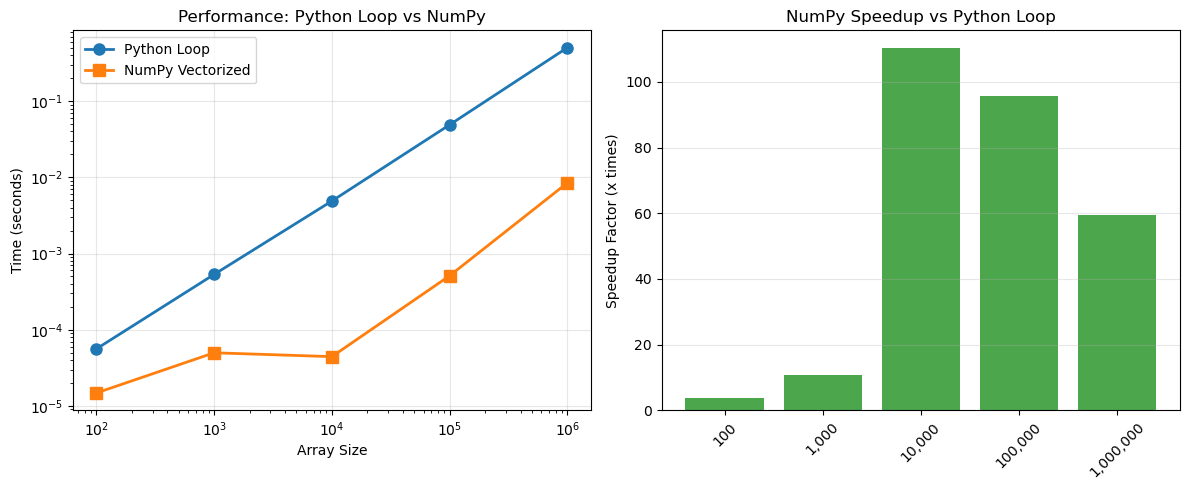

Speedup factors: ['4x', '11x', '110x', '96x', '60x']


In [5]:
# Visualizing the speedup with different array sizes
import matplotlib.pyplot as plt

sizes = [100, 1000, 10000, 100000, 1000000]
loop_times = []
numpy_times = []

for size in sizes:
    a = np.random.rand(size)
    b = np.random.rand(size)
    a_list = a.tolist()
    b_list = b.tolist()
    
    # Time Python loop
    start = time.time()
    [a_list[i] + b_list[i] for i in range(size)]
    loop_times.append(time.time() - start)
    
    # Time NumPy
    start = time.time()
    a + b
    numpy_times.append(time.time() - start)

speedups = [l/n for l, n in zip(loop_times, numpy_times)]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(sizes, loop_times, 'o-', label='Python Loop', linewidth=2, markersize=8)
plt.plot(sizes, numpy_times, 's-', label='NumPy Vectorized', linewidth=2, markersize=8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Array Size')
plt.ylabel('Time (seconds)')
plt.title('Performance: Python Loop vs NumPy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(len(sizes)), speedups, color='green', alpha=0.7)
plt.xticks(range(len(sizes)), [f'{s:,}' for s in sizes], rotation=45)
plt.ylabel('Speedup Factor (x times)')
plt.title('NumPy Speedup vs Python Loop')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Speedup factors:", [f"{s:.0f}x" for s in speedups])

## 5. Mathematical Operations & Broadcasting {#math-ops}

NumPy operations are element-wise by default. Broadcasting allows operations between arrays of different shapes:

In [6]:
# Element-wise arithmetic
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

print(f"a = {a}")
print(f"b = {b}")
print(f"a + b = {a + b}")
print(f"a - b = {a - b}")
print(f"a * b = {a * b}")  # Element-wise multiplication, NOT matrix multiplication
print(f"a / b = {a / b}")
print(f"a ** 2 = {a ** 2}")
print(f"a + 10 = {a + 10}")  # Scalar broadcasting

# Broadcasting examples (crucial for ML operations)
print("\n--- Broadcasting Examples ---")
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
row_vector = np.array([10, 20, 30])
col_vector = np.array([[100], [200], [300]])

print(f"Matrix shape: {matrix.shape}")
print(f"Row vector shape: {row_vector.shape}")
print(f"Matrix + row vector:\n{matrix + row_vector}")  # Adds to each row

print(f"\nColumn vector shape: {col_vector.shape}")
print(f"Matrix + column vector:\n{matrix + col_vector}")  # Adds to each column

# Practical ML example: Normalizing a batch of data
batch = np.random.randint(0, 100, size=(5, 3))  # 5 samples, 3 features
mean = batch.mean(axis=0)  # Mean of each feature
std = batch.std(axis=0)    # Std of each feature
normalized = (batch - mean) / std  # Broadcasting!
print(f"\nOriginal batch:\n{batch}")
print(f"Normalized batch:\n{normalized}")
print(f"Normalized mean (should be ~0): {normalized.mean(axis=0)}")
print(f"Normalized std (should be ~1): {normalized.std(axis=0)}")

a = [1 2 3 4]
b = [10 20 30 40]
a + b = [11 22 33 44]
a - b = [ -9 -18 -27 -36]
a * b = [ 10  40  90 160]
a / b = [0.1 0.1 0.1 0.1]
a ** 2 = [ 1  4  9 16]
a + 10 = [11 12 13 14]

--- Broadcasting Examples ---
Matrix shape: (3, 3)
Row vector shape: (3,)
Matrix + row vector:
[[11 22 33]
 [14 25 36]
 [17 28 39]]

Column vector shape: (3, 1)
Matrix + column vector:
[[101 102 103]
 [204 205 206]
 [307 308 309]]

Original batch:
[[28 48 45]
 [98 63 34]
 [22 69 22]
 [70 52 17]
 [79 72 40]]
Normalized batch:
[[-1.06197504 -1.36634906  1.26482654]
 [ 1.30548525  0.23484124  0.2265361 ]
 [-1.26490021  0.87531737 -0.90614439]
 [ 0.35850113 -0.93936498 -1.37809459]
 [ 0.66288888  1.19555543  0.79287634]]
Normalized mean (should be ~0): [ 4.44089210e-17  3.10862447e-16 -1.55431223e-16]
Normalized std (should be ~1): [1. 1. 1.]


## 6. Universal Functions (ufuncs) {#ufuncs}

Universal functions operate element-wise and are highly optimized. They're used everywhere in ML for activations, transformations, and preprocessing:

Original: [ 1  4  9 16 25]
Square root (np.sqrt): [1. 2. 3. 4. 5.]
Exponential (np.exp): [2.71828183e+00 5.45981500e+01 8.10308393e+03 8.88611052e+06
 7.20048993e+10]
Natural log (np.log): [0.         1.38629436 2.19722458 2.77258872 3.21887582]
Log base 10 (np.log10): [0.         0.60205999 0.95424251 1.20411998 1.39794001]
Sin (np.sin): [ 0.84147098 -0.7568025   0.41211849 -0.28790332 -0.13235175]
Cos (np.cos): [ 0.54030231 -0.65364362 -0.91113026 -0.95765948  0.99120281]
Absolute value (np.abs): [1 2 3 4]
Ceiling (np.ceil): [2. 3. 4.]
Floor (np.floor): [1. 2. 3.]
Round (np.round): [1.23 2.57 3.89]


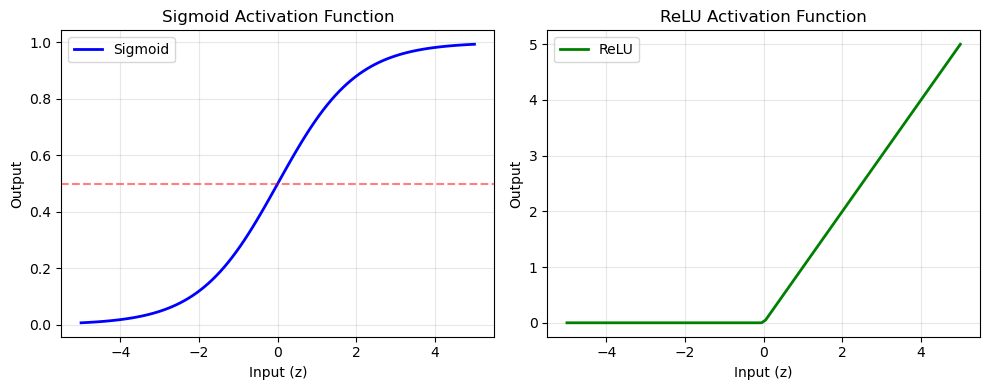

In [7]:
arr = np.array([1, 4, 9, 16, 25])

# Common mathematical ufuncs
print(f"Original: {arr}")
print(f"Square root (np.sqrt): {np.sqrt(arr)}")
print(f"Exponential (np.exp): {np.exp(arr)}")
print(f"Natural log (np.log): {np.log(arr)}")
print(f"Log base 10 (np.log10): {np.log10(arr)}")
print(f"Sin (np.sin): {np.sin(arr)}")
print(f"Cos (np.cos): {np.cos(arr)}")
print(f"Absolute value (np.abs): {np.abs([-1, -2, 3, -4])}")
print(f"Ceiling (np.ceil): {np.ceil([1.2, 2.5, 3.7])}")
print(f"Floor (np.floor): {np.floor([1.2, 2.5, 3.7])}")
print(f"Round (np.round): {np.round([1.234, 2.567, 3.891], decimals=2)}")

# ML-specific examples
# Sigmoid activation function (common in neural networks)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

z = np.linspace(-5, 5, 100)
sigmoid_values = sigmoid(z)

# ReLU activation
def relu(x):
    return np.maximum(0, x)

relu_values = relu(z)

# Plotting activation functions
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(z, sigmoid_values, 'b-', linewidth=2, label='Sigmoid')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.title('Sigmoid Activation Function')
plt.xlabel('Input (z)')
plt.ylabel('Output')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(z, relu_values, 'g-', linewidth=2, label='ReLU')
plt.title('ReLU Activation Function')
plt.xlabel('Input (z)')
plt.ylabel('Output')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Aggregation Functions {#aggregation}

Aggregation functions reduce arrays to summary statistics—essential for model evaluation and data analysis:

Data shape: (100, 5)

--- Summary Statistics ---
Sum: 3.4190
Mean: 0.0068
Standard deviation: 0.9803
Variance: 0.9609
Min: -3.2413
Max: 3.8527
Median: 0.0128
25th percentile: -0.7003
75th percentile: 0.6368

--- Per-Feature Statistics (axis=0) ---
Mean per feature: [-0.04474719  0.07695423 -0.09387351  0.12805847 -0.03220203]
Std per feature: [0.89583921 0.9791772  0.97901142 0.95474576 1.06742857]
Min per feature: [-1.9520878  -2.30192116 -3.24126734 -1.91328024 -2.6197451 ]
Max per feature: [2.31465857 1.8861859  2.1221562  3.07888081 3.85273149]

--- Per-Sample Statistics (axis=1) ---
Mean of first 5 samples: [ 0.45900297  0.43711925 -0.86507665 -0.71623982 -0.13234605]


C:\Users\786\AppData\Local\Temp\ipykernel_8152\1176267060.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data[:, i] for i in range(5)], labels=[f'F{i+1}' for i in range(5)])


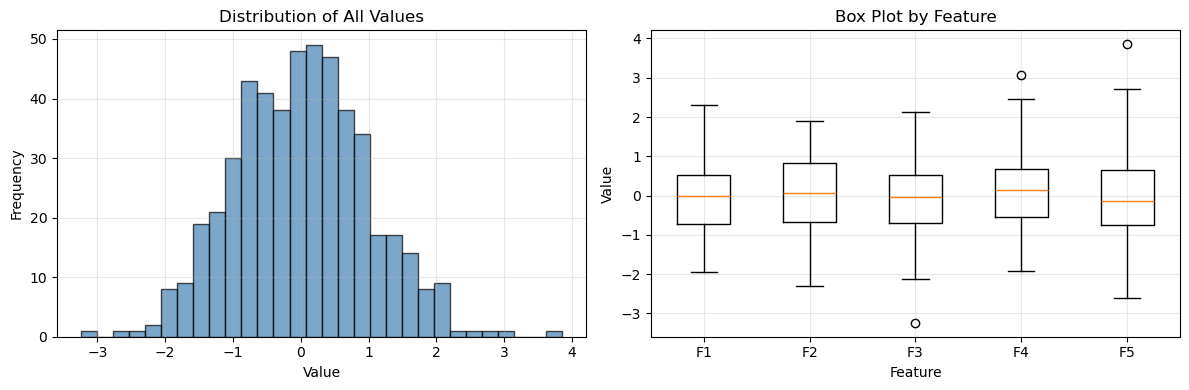

In [8]:
np.random.seed(42)
data = np.random.randn(100, 5)  # 100 samples, 5 features

print(f"Data shape: {data.shape}")
print(f"\n--- Summary Statistics ---")
print(f"Sum: {np.sum(data):.4f}")
print(f"Mean: {np.mean(data):.4f}")
print(f"Standard deviation: {np.std(data):.4f}")
print(f"Variance: {np.var(data):.4f}")
print(f"Min: {np.min(data):.4f}")
print(f"Max: {np.max(data):.4f}")
print(f"Median: {np.median(data):.4f}")
print(f"25th percentile: {np.percentile(data, 25):.4f}")
print(f"75th percentile: {np.percentile(data, 75):.4f}")

# Axis-wise operations (critical for ML: computing statistics per feature)
print(f"\n--- Per-Feature Statistics (axis=0) ---")
print(f"Mean per feature: {np.mean(data, axis=0)}")
print(f"Std per feature: {np.std(data, axis=0)}")
print(f"Min per feature: {np.min(data, axis=0)}")
print(f"Max per feature: {np.max(data, axis=0)}")

# Per-sample statistics (axis=1)
print(f"\n--- Per-Sample Statistics (axis=1) ---")
print(f"Mean of first 5 samples: {np.mean(data, axis=1)[:5]}")

# Histogram visualization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data.flatten(), bins=30, color='steelblue', alpha=0.7, edgecolor='black')
plt.title('Distribution of All Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([data[:, i] for i in range(5)], labels=[f'F{i+1}' for i in range(5)])
plt.title('Box Plot by Feature')
plt.xlabel('Feature')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Boolean Indexing & Masking {#boolean-indexing}

Boolean indexing allows you to filter arrays based on conditions—essential for data cleaning and conditional operations:

In [9]:
np.random.seed(42)
data = np.random.randint(0, 100, size=20)
print(f"Data: {data}")

# Boolean masks
mask_greater_50 = data > 50
print(f"\nMask (>50): {mask_greater_50}")
print(f"Values > 50: {data[mask_greater_50]}")

# Direct boolean indexing
print(f"Values between 30 and 70: {data[(data >= 30) & (data <= 70)]}")
print(f"Values < 20 or > 80: {data[(data < 20) | (data > 80)]}")
print(f"Values NOT > 50: {data[~(data > 50)]}")

# Modifying values with boolean indexing
data_clean = data.copy()
data_clean[data_clean > 80] = 80  # Cap values at 80
data_clean[data_clean < 20] = 20  # Floor values at 20
print(f"\nClipped data (20-80): {data_clean}")

# np.where for conditional assignment
categories = np.where(data > 50, 'High', 'Low')
print(f"Categories: {categories}")

# Counting with boolean indexing
print(f"\nCount > 50: {np.sum(data > 50)}")
print(f"Count between 30-60: {np.sum((data >= 30) & (data <= 60))}")
print(f"Any > 90? {np.any(data > 90)}")
print(f"All > 0? {np.all(data > 0)}")

# 2D boolean indexing
matrix = np.random.randint(0, 10, size=(5, 5))
print(f"\nMatrix:\n{matrix}")
print(f"Elements > 5: {matrix[matrix > 5]}")
print(f"Count per row (>5): {np.sum(matrix > 5, axis=1)}")

Data: [51 92 14 71 60 20 82 86 74 74 87 99 23  2 21 52  1 87 29 37]

Mask (>50): [ True  True False  True  True False  True  True  True  True  True  True
 False False False  True False  True False False]
Values > 50: [51 92 71 60 82 86 74 74 87 99 52 87]
Values between 30 and 70: [51 60 52 37]
Values < 20 or > 80: [92 14 82 86 87 99  2  1 87]
Values NOT > 50: [14 20 23  2 21  1 29 37]

Clipped data (20-80): [51 80 20 71 60 20 80 80 74 74 80 80 23 20 21 52 20 80 29 37]
Categories: ['High' 'High' 'Low' 'High' 'High' 'Low' 'High' 'High' 'High' 'High'
 'High' 'High' 'Low' 'Low' 'Low' 'High' 'Low' 'High' 'Low' 'Low']

Count > 50: 12
Count between 30-60: 4
Any > 90? True
All > 0? True

Matrix:
[[1 4 0 9 5]
 [8 0 9 2 6]
 [3 8 2 4 2]
 [6 4 8 6 1]
 [3 8 1 9 8]]
Elements > 5: [9 8 9 6 8 6 8 6 8 9 8]
Count per row (>5): [1 3 1 3 3]


## 9. Reshaping, Transposing & Flattening {#reshaping}

Reshaping is fundamental in ML for preparing data for different layers and operations:

Original (1D): (24,)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Reshaped to (4, 6):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]

Reshaped to (2, 3, 4):
[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]

Reshaped to (3, -1) -> (3, 8):
[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]]

Original shape: (4, 6)
Transposed shape: (6, 4)
Transposed:
[[ 0  6 12 18]
 [ 1  7 13 19]
 [ 2  8 14 20]
 [ 3  9 15 21]
 [ 4 10 16 22]
 [ 5 11 17 23]]

Flatten: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Ravel: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Single image shape: (28, 28)
Batch image shape: (1, 28, 28)
Using expand_dims: (1, 28, 28)
Squeezed shape: (28, 28)


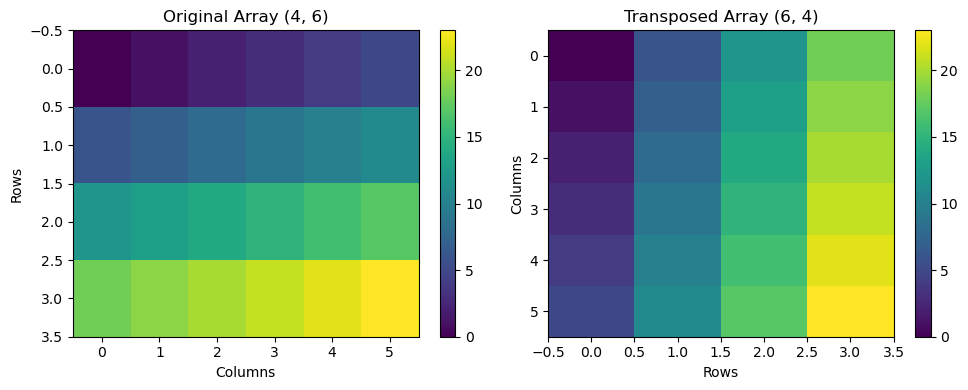

In [10]:
arr = np.arange(24)
print(f"Original (1D): {arr.shape}\n{arr}")

# Reshape to 2D
arr_2d = arr.reshape(4, 6)
print(f"\nReshaped to (4, 6):\n{arr_2d}")

# Reshape to 3D
arr_3d = arr.reshape(2, 3, 4)
print(f"\nReshaped to (2, 3, 4):\n{arr_3d}")

# -1 lets NumPy infer the dimension
arr_infer = arr.reshape(3, -1)
print(f"\nReshaped to (3, -1) -> {arr_infer.shape}:\n{arr_infer}")

# Transpose (swap axes)
print(f"\nOriginal shape: {arr_2d.shape}")
print(f"Transposed shape: {arr_2d.T.shape}")
print(f"Transposed:\n{arr_2d.T}")

# Flatten (returns copy) vs Ravel (returns view when possible)
flat = arr_2d.flatten()
ravel = arr_2d.ravel()
print(f"\nFlatten: {flat}")
print(f"Ravel: {ravel}")

# Expand dimensions (adding batch dimension)
single_image = np.random.rand(28, 28)  # Single grayscale image
batch_image = single_image[np.newaxis, :, :]  # Add batch dimension
print(f"\nSingle image shape: {single_image.shape}")
print(f"Batch image shape: {batch_image.shape}")

# Or use expand_dims
batch_image2 = np.expand_dims(single_image, axis=0)
print(f"Using expand_dims: {batch_image2.shape}")

# Squeeze removes dimensions of size 1
squeezed = batch_image.squeeze()
print(f"Squeezed shape: {squeezed.shape}")

# Visualize reshaping with a heatmap
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(arr_2d, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title(f'Original Array {arr_2d.shape}')
plt.xlabel('Columns')
plt.ylabel('Rows')

plt.subplot(1, 2, 2)
plt.imshow(arr_2d.T, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title(f'Transposed Array {arr_2d.T.shape}')
plt.xlabel('Rows')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

## 10. Common AI/ML Patterns {#ml-patterns}

Let's put it all together with patterns you'll use constantly in machine learning:

Weight matrix shape: (784, 256)
Weight stats - Mean: 0.0001, Std: 0.0438

Original data range: [0, 996]
Scaled data mean: [ 1.50990331e-16  9.10382880e-17  9.68669589e-17 -9.04831765e-17
 -6.99440506e-17]
Scaled data std: [1. 1. 1. 1. 1.]
Min-max scaled range: [0.00, 1.00]

Number of batches: 5
First batch X shape: (20, 10)
First batch y shape: (20,)

Labels: [0 2 1 3]
One-hot encoded:
[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]

Distances shape: (100,)
Closest point distance: 0.1196


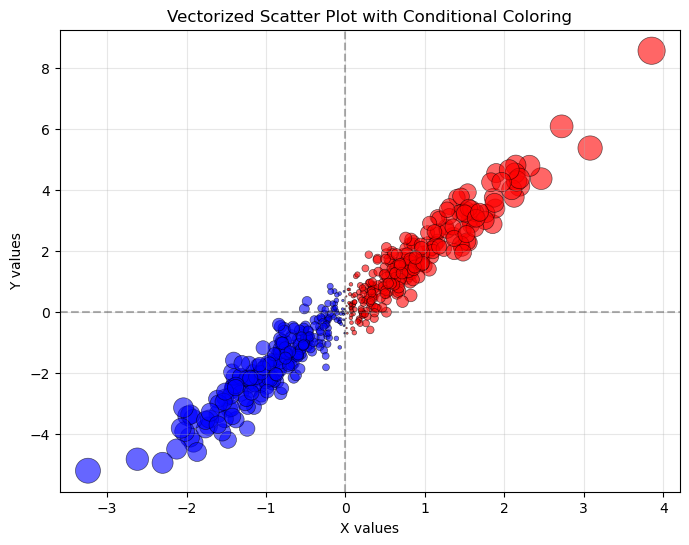

In [11]:
np.random.seed(42)

# Pattern 1: Creating random weight matrices for neural networks
def initialize_weights(input_size, output_size, method='xavier'):
    if method == 'xavier':
        # Xavier/Glorot initialization
        limit = np.sqrt(6 / (input_size + output_size))
        return np.random.uniform(-limit, limit, size=(input_size, output_size))
    elif method == 'he':
        # He initialization
        return np.random.randn(input_size, output_size) * np.sqrt(2 / input_size)
    else:
        return np.random.randn(input_size, output_size) * 0.01

weights = initialize_weights(784, 256, method='xavier')
print(f"Weight matrix shape: {weights.shape}")
print(f"Weight stats - Mean: {weights.mean():.4f}, Std: {weights.std():.4f}")

# Pattern 2: Feature scaling (Standardization)
def standardize_features(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    # Avoid division by zero
    std[std == 0] = 1
    return (X - mean) / std, mean, std

X_raw = np.random.randint(0, 1000, size=(100, 5))
X_scaled, mean, std = standardize_features(X_raw)
print(f"\nOriginal data range: [{X_raw.min()}, {X_raw.max()}]")
print(f"Scaled data mean: {X_scaled.mean(axis=0)}")
print(f"Scaled data std: {X_scaled.std(axis=0)}")

# Pattern 3: Min-Max scaling to [0, 1]
def min_max_scale(X):
    X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)
    return (X - X_min) / (X_max - X_min)

X_normalized = min_max_scale(X_raw)
print(f"Min-max scaled range: [{X_normalized.min():.2f}, {X_normalized.max():.2f}]")

# Pattern 4: Batch processing (simulating mini-batch gradient descent)
def create_batches(X, y, batch_size=32):
    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    
    batches = []
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        batches.append((X_batch, y_batch))
    return batches

X = np.random.randn(100, 10)
y = np.random.randint(0, 2, size=100)
batches = create_batches(X, y, batch_size=20)
print(f"\nNumber of batches: {len(batches)}")
print(f"First batch X shape: {batches[0][0].shape}")
print(f"First batch y shape: {batches[0][1].shape}")

# Pattern 5: One-hot encoding
def one_hot_encode(labels, num_classes):
    return np.eye(num_classes)[labels]

labels = np.array([0, 2, 1, 3])
one_hot = one_hot_encode(labels, num_classes=4)
print(f"\nLabels: {labels}")
print(f"One-hot encoded:\n{one_hot}")

# Pattern 6: Distance computation (vectorized)
def euclidean_distance(X, point):
    # X: (n_samples, n_features), point: (n_features,)
    return np.sqrt(np.sum((X - point) ** 2, axis=1))

points = np.random.randn(100, 3)
query = np.array([0, 0, 0])
distances = euclidean_distance(points, query)
print(f"\nDistances shape: {distances.shape}")
print(f"Closest point distance: {distances.min():.4f}")

# Pattern 7: Scatter plot with vectorized operations
np.random.seed(42)
n_points = 500
x = np.random.randn(n_points)
y = 2 * x + np.random.randn(n_points) * 0.5  # Linear relationship with noise
colors = np.where(x > 0, 'red', 'blue')
sizes = np.abs(x) * 100

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=colors, s=sizes, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.title('Vectorized Scatter Plot with Conditional Coloring')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.grid(True, alpha=0.3)
plt.show()

## 🛠️ Hands-On Exercises {#exercises}

Complete these exercises to solidify your NumPy skills. Try to solve them without using Python loops!

### Exercise 1: Array Creation
Create a 1D array containing the numbers 0 to 9, a 2D array of shape (3, 3) filled with ones, and a 3x3 identity matrix.

In [12]:
# your code here


### Exercise 2: Slicing Practice
Given the array `arr = np.arange(20).reshape(4, 5)`, extract:
1. The second row
2. The third column
3. A 2x2 subarray from the bottom-right corner
4. All even numbers from the array

In [13]:
# your code here


### Exercise 3: Vectorized vs Loop
Create two arrays of size 1,000,000. Compare the time taken to compute their element-wise product using:
1. A Python loop
2. A list comprehension
3. NumPy vectorized multiplication
Print the speedup factors.

In [14]:
# your code here


### Exercise 4: Broadcasting
Create a 5x5 matrix of random integers between 0 and 100. Subtract the mean of each row from that row (using broadcasting). Verify that each row now has a mean of approximately 0.

In [15]:
# your code here


### Exercise 5: Statistical Computations
Generate a 100x4 array of random numbers (representing 100 samples with 4 features). Compute:
1. Mean and standard deviation of each feature
2. The correlation between feature 0 and feature 1
3. The sample with the maximum sum of all features

In [16]:
# your code here


### Exercise 6: Boolean Masking
Create an array of 1000 random integers between -50 and 50. Count how many are positive, negative, and zero. Replace all negative values with their absolute values.

In [17]:
# your code here


### Exercise 7: Reshaping for ML Data
You have 1000 images, each 28x28 pixels (grayscale). Create a random dataset with this shape, then reshape it to:
1. (1000, 784) - flattened for a dense layer
2. (1000, 28, 28, 1) - for a CNN (adding channel dimension)
Print the shapes to verify.

In [18]:
# your code here


### Exercise 8: Feature Normalization Function
Implement a function `normalize_features(X, method='standard')` that takes a 2D array and returns normalized data. Support:
- `method='standard'`: Zero mean, unit variance
- `method='minmax'`: Scale to [0, 1]
- `method='robust'`: Subtract median, divide by IQR (75th - 25th percentile)
Return both the normalized data and the statistics used (for applying to new data).

In [19]:
# your code here


### Exercise 9: Distance Matrix
Given a set of points `X` of shape (n, d) and query points `Q` of shape (m, d), compute the Euclidean distance between every point in X and every point in Q. The result should be a matrix of shape (n, m) where element [i, j] is the distance between X[i] and Q[j]. Do this using broadcasting without loops.

In [20]:
# your code here


### Exercise 10: Neural Network Forward Pass
Implement a simple forward pass function that takes input X, weights W1 and W2, and biases b1 and b2, and computes:
- Hidden layer: `h = relu(X @ W1 + b1)`
- Output layer: `y = sigmoid(h @ W2 + b2)`
Use the sigmoid and ReLU implementations from earlier. Test with random data of appropriate shapes.

In [21]:
# your code here


### Exercise 11: K-Nearest Neighbors (Vectorized)
Implement a function that finds the k nearest neighbors for each point in a query set from a training set. Use vectorized operations (no loops over the query set). Return the indices of the k nearest neighbors for each query point.

In [22]:
# your code here


## Solutions {#solutions}

Check your answers after attempting the exercises!

### Solution 1: Array Creation

In [23]:
import numpy as np

# 1D array 0-9
arr_1d = np.arange(10)
print(f"1D array: {arr_1d}")

# 2D array of ones
arr_ones = np.ones((3, 3))
print(f"2D ones:\n{arr_ones}")

# Identity matrix
identity = np.eye(3)
print(f"Identity matrix:\n{identity}")

# Expected output:
# 1D array: [0 1 2 3 4 5 6 7 8 9]
# 2D ones:
# [[1. 1. 1.]
#  [1. 1. 1.]
#  [1. 1. 1.]]
# Identity matrix:
# [[1. 0. 0.]
#  [0. 1. 0.]
#  [0. 0. 1.]]

1D array: [0 1 2 3 4 5 6 7 8 9]
2D ones:
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
Identity matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### Solution 2: Slicing Practice

In [24]:
arr = np.arange(20).reshape(4, 5)
print(f"Original array:\n{arr}\n")

# Second row
second_row = arr[1, :]
print(f"Second row: {second_row}")

# Third column
third_col = arr[:, 2]
print(f"Third column: {third_col}")

# Bottom-right 2x2
subarray = arr[2:4, 3:5]
print(f"Bottom-right 2x2:\n{subarray}")

# All even numbers
evens = arr[arr % 2 == 0]
print(f"Even numbers: {evens}")

# Expected output:
# Second row: [5 6 7 8 9]
# Third column: [ 2  7 12 17]
# Bottom-right 2x2:
# [[13 14]
#  [18 19]]
# Even numbers: [ 0  2  4  6  8 10 12 14 16 18]

Original array:
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]

Second row: [5 6 7 8 9]
Third column: [ 2  7 12 17]
Bottom-right 2x2:
[[13 14]
 [18 19]]
Even numbers: [ 0  2  4  6  8 10 12 14 16 18]


### Solution 3: Vectorized vs Loop

In [25]:
import time

size = 1000000
a = np.random.rand(size)
b = np.random.rand(size)
a_list = a.tolist()
b_list = b.tolist()

# Python loop
start = time.time()
result_loop = []
for i in range(size):
    result_loop.append(a_list[i] * b_list[i])
loop_time = time.time() - start

# List comprehension
start = time.time()
result_list = [a_list[i] * b_list[i] for i in range(size)]
list_time = time.time() - start

# NumPy
start = time.time()
result_numpy = a * b
numpy_time = time.time() - start

print(f"Python loop: {loop_time:.4f}s")
print(f"List comprehension: {list_time:.4f}s")
print(f"NumPy: {numpy_time:.4f}s")
print(f"Speedup vs loop: {loop_time/numpy_time:.0f}x")
print(f"Speedup vs list comp: {list_time/numpy_time:.0f}x")

# Expected: NumPy should be 50-200x faster than loops

Python loop: 0.6638s
List comprehension: 0.4758s
NumPy: 0.0067s
Speedup vs loop: 99x
Speedup vs list comp: 71x


### Solution 4: Broadcasting

In [26]:
np.random.seed(42)
matrix = np.random.randint(0, 100, size=(5, 5))
print(f"Original matrix:\n{matrix}")
print(f"Row means: {matrix.mean(axis=1)}")

# Subtract row means using broadcasting
centered = matrix - matrix.mean(axis=1, keepdims=True)
print(f"\nCentered matrix:\n{centered}")
print(f"New row means (should be ~0): {centered.mean(axis=1)}")

# Expected: Row means should be very close to 0 (may have tiny floating point errors)

Original matrix:
[[51 92 14 71 60]
 [20 82 86 74 74]
 [87 99 23  2 21]
 [52  1 87 29 37]
 [ 1 63 59 20 32]]
Row means: [57.6 67.2 46.4 41.2 35. ]

Centered matrix:
[[ -6.6  34.4 -43.6  13.4   2.4]
 [-47.2  14.8  18.8   6.8   6.8]
 [ 40.6  52.6 -23.4 -44.4 -25.4]
 [ 10.8 -40.2  45.8 -12.2  -4.2]
 [-34.   28.   24.  -15.   -3. ]]
New row means (should be ~0): [-1.42108547e-15 -2.84217094e-15  2.84217094e-15 -2.84217094e-15
  0.00000000e+00]


### Solution 5: Statistical Computations

In [27]:
np.random.seed(42)
data = np.random.randn(100, 4)

# 1. Mean and std of each feature
means = np.mean(data, axis=0)
stds = np.std(data, axis=0)
print(f"Feature means: {means}")
print(f"Feature stds: {stds}")

# 2. Correlation between feature 0 and 1
corr = np.corrcoef(data[:, 0], data[:, 1])[0, 1]
print(f"Correlation (feat 0 vs 1): {corr:.4f}")

# 3. Sample with maximum sum
sample_sums = np.sum(data, axis=1)
max_idx = np.argmax(sample_sums)
print(f"Sample with max sum (index {max_idx}): {data[max_idx]}")
print(f"Sum of this sample: {sample_sums[max_idx]:.4f}")

# Expected: Correlation should be between -1 and 1, typically small for random data

Feature means: [-0.00981123  0.0337458   0.0224957   0.04376417]
Feature stds: [0.86371336 0.94746077 1.03878064 0.97731629]
Correlation (feat 0 vs 1): -0.0164
Sample with max sum (index 52): [0.51504769 3.85273149 0.57089051 1.13556564]
Sum of this sample: 6.0742


### Solution 6: Boolean Masking

In [28]:
np.random.seed(42)
arr = np.random.randint(-50, 51, size=1000)

# Count positive, negative, zero
positive_count = np.sum(arr > 0)
negative_count = np.sum(arr < 0)
zero_count = np.sum(arr == 0)

print(f"Positive: {positive_count}")
print(f"Negative: {negative_count}")
print(f"Zero: {zero_count}")
print(f"Total: {positive_count + negative_count + zero_count}")

# Replace negatives with absolute values
arr_abs = arr.copy()
arr_abs[arr_abs < 0] = np.abs(arr_abs[arr_abs < 0])
print(f"\nMin value after fix: {arr_abs.min()} (should be >= 0)")

# Expected: Positive and negative counts should be roughly equal (~500 each), zeros rare (~10-20)

Positive: 498
Negative: 489
Zero: 13
Total: 1000

Min value after fix: 0 (should be >= 0)


### Solution 7: Reshaping for ML Data

In [29]:
# Create image dataset
images = np.random.rand(1000, 28, 28)
print(f"Original shape: {images.shape}")

# Flatten for dense layer
flat = images.reshape(1000, -1)
print(f"Flattened shape: {flat.shape}")

# Add channel dimension for CNN
cnn_ready = images.reshape(1000, 28, 28, 1)
# Or: cnn_ready = images[..., np.newaxis]
print(f"CNN shape: {cnn_ready.shape}")

# Verify
assert flat.shape == (1000, 784)
assert cnn_ready.shape == (1000, 28, 28, 1)
print("\nShapes verified successfully!")

# Expected:
# Original shape: (1000, 28, 28)
# Flattened shape: (1000, 784)
# CNN shape: (1000, 28, 28, 1)

Original shape: (1000, 28, 28)
Flattened shape: (1000, 784)
CNN shape: (1000, 28, 28, 1)

Shapes verified successfully!


### Solution 8: Feature Normalization Function

In [30]:
def normalize_features(X, method='standard'):
    stats = {}
    
    if method == 'standard':
        mean = np.mean(X, axis=0)
        std = np.std(X, axis=0)
        std[std == 0] = 1  # Avoid division by zero
        X_norm = (X - mean) / std
        stats = {'mean': mean, 'std': std}
        
    elif method == 'minmax':
        X_min = np.min(X, axis=0)
        X_max = np.max(X, axis=0)
        range_val = X_max - X_min
        range_val[range_val == 0] = 1
        X_norm = (X - X_min) / range_val
        stats = {'min': X_min, 'max': X_max}
        
    elif method == 'robust':
        median = np.median(X, axis=0)
        q25 = np.percentile(X, 25, axis=0)
        q75 = np.percentile(X, 75, axis=0)
        iqr = q75 - q25
        iqr[iqr == 0] = 1
        X_norm = (X - median) / iqr
        stats = {'median': median, 'q25': q25, 'q75': q75, 'iqr': iqr}
    
    return X_norm, stats

# Test
np.random.seed(42)
X = np.random.randn(100, 3) * 10 + 5  # Mean ~5, std ~10

X_std, stats_std = normalize_features(X, 'standard')
X_minmax, stats_minmax = normalize_features(X, 'minmax')
X_robust, stats_robust = normalize_features(X, 'robust')

print(f"Standard - Mean: {X_std.mean(axis=0)}, Std: {X_std.std(axis=0)}")
print(f"MinMax - Min: {X_minmax.min(axis=0)}, Max: {X_minmax.max(axis=0)}")
print(f"Robust - Median: {np.median(X_robust, axis=0)}")

# Expected:
# Standard: Mean ~0, Std ~1
# MinMax: Min ~0, Max ~1
# Robust: Median ~0

Standard - Mean: [1.11577414e-16 6.66133815e-17 3.21964677e-17], Std: [1. 1. 1.]
MinMax - Min: [0. 0. 0.], Max: [1. 1. 1.]
Robust - Median: [ 0.00000000e+00  0.00000000e+00 -3.03576608e-17]


### Solution 9: Distance Matrix

In [31]:
def pairwise_distances(X, Q):
    # X: (n, d), Q: (m, d)
    # Using broadcasting: (n, 1, d) - (1, m, d) -> (n, m, d)
    diff = X[:, np.newaxis, :] - Q[np.newaxis, :, :]
    distances = np.sqrt(np.sum(diff ** 2, axis=2))
    return distances

# Alternative memory-efficient version
def pairwise_distances_efficient(X, Q):
    # ||x - q||^2 = ||x||^2 + ||q||^2 - 2*x.q
    X_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)
    Q_sq = np.sum(Q ** 2, axis=1).reshape(1, -1)
    distances = np.sqrt(X_sq + Q_sq - 2 * X @ Q.T)
    return distances

# Test
X = np.random.randn(5, 3)
Q = np.random.randn(3, 3)

D = pairwise_distances(X, Q)
print(f"Distance matrix shape: {D.shape}")
print(f"Distance matrix:\n{D}")

# Verify with manual calculation for first pair
manual_dist = np.sqrt(np.sum((X[0] - Q[0]) ** 2))
print(f"\nManual check [0,0]: {manual_dist:.4f}")
print(f"Computed [0,0]: {D[0, 0]:.4f}")

# Expected: Shape (5, 3), manual and computed distances should match

Distance matrix shape: (5, 3)
Distance matrix:
[[1.83951865 1.39197731 1.97587208]
 [1.01202474 0.3070175  2.12997905]
 [1.9839694  1.15094173 1.70443766]
 [1.686583   1.13502497 1.40843028]
 [1.80970173 1.61312205 1.82614023]]

Manual check [0,0]: 1.8395
Computed [0,0]: 1.8395


### Solution 10: Neural Network Forward Pass

In [32]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def forward_pass(X, W1, b1, W2, b2):
    # X: (batch_size, input_dim)
    # W1: (input_dim, hidden_dim), b1: (hidden_dim,)
    # W2: (hidden_dim, output_dim), b2: (output_dim,)
    
    # Hidden layer
    z1 = X @ W1 + b1  # Linear transformation
    h = relu(z1)      # Activation
    
    # Output layer
    z2 = h @ W2 + b2  # Linear transformation
    y = sigmoid(z2)   # Activation
    
    return y, h  # Return output and hidden activations

# Test with random data
np.random.seed(42)
batch_size = 10
input_dim = 5
hidden_dim = 3
output_dim = 1

X = np.random.randn(batch_size, input_dim)
W1 = np.random.randn(input_dim, hidden_dim) * 0.1
b1 = np.zeros(hidden_dim)
W2 = np.random.randn(hidden_dim, output_dim) * 0.1
b2 = np.zeros(output_dim)

output, hidden = forward_pass(X, W1, b1, W2, b2)
print(f"Input shape: {X.shape}")
print(f"Hidden shape: {hidden.shape}")
print(f"Output shape: {output.shape}")
print(f"Output range: [{output.min():.4f}, {output.max():.4f}]")

# Expected: Output shape (10, 1), values between 0 and 1 (sigmoid output)

Input shape: (10, 5)
Hidden shape: (10, 3)
Output shape: (10, 1)
Output range: [0.4995, 0.5072]


### Solution 11: K-Nearest Neighbors (Vectorized)

In [33]:
def knn_vectorized(X_train, X_query, k=3):
    # X_train: (n_train, d), X_query: (n_query, d)
    # Returns: (n_query, k) indices of nearest neighbors
    
    # Compute all pairwise distances: (n_query, n_train)
    dists = np.sqrt(
        np.sum(X_train ** 2, axis=1) + 
        np.sum(X_query ** 2, axis=1)[:, np.newaxis] - 
        2 * X_query @ X_train.T
    )
    
    # Get k smallest distances for each query
    # np.argpartition is O(n) vs sorting O(n log n)
    nearest_idx = np.argpartition(dists, k, axis=1)[:, :k]
    
    # Optional: Sort the k neighbors by actual distance
    # Get distances for the k nearest
    k_dists = np.take_along_axis(dists, nearest_idx, axis=1)
    # Sort within the k neighbors
    sorted_order = np.argsort(k_dists, axis=1)
    nearest_idx = np.take_along_axis(nearest_idx, sorted_order, axis=1)
    
    return nearest_idx

# Test
np.random.seed(42)
X_train = np.random.randn(100, 5)
X_query = np.random.randn(5, 5)

nearest = knn_vectorized(X_train, X_query, k=3)
print(f"Query shape: {X_query.shape}")
print(f"Nearest neighbors shape: {nearest.shape}")
print(f"Nearest neighbor indices for each query:\n{nearest}")

# Verify first query point manually
dists_manual = np.sqrt(np.sum((X_train - X_query[0]) ** 2, axis=1))
manual_nearest = np.argsort(dists_manual)[:3]
print(f"\nManual verification for query 0: {manual_nearest}")
print(f"Vectorized result for query 0: {nearest[0]}")
print(f"Match: {np.array_equal(sorted(nearest[0]), sorted(manual_nearest))}")

# Expected: Shape (5, 3), indices should match manual calculation

Query shape: (5, 5)
Nearest neighbors shape: (5, 3)
Nearest neighbor indices for each query:
[[28 61 90]
 [67 96 91]
 [89 55 43]
 [30 45 10]
 [26 71 19]]

Manual verification for query 0: [28 61 90]
Vectorized result for query 0: [28 61 90]
Match: True


---

## 🎉 Congratulations on Completing Day 10!

You've mastered the fundamentals of NumPy arrays and vectorization—the bedrock of efficient AI and ML code. Remember: **always prefer vectorized operations over Python loops** when working with numerical data. The performance gains are enormous, and your future self (and your training pipelines) will thank you.

### Key Takeaways:
- ✅ NumPy arrays are contiguous in memory and operations are implemented in C
- ✅ Vectorization can speed up code by 100x or more compared to Python loops
- ✅ Broadcasting allows elegant operations between arrays of different shapes
- ✅ Boolean indexing and masking are powerful tools for data filtering
- ✅ Reshaping is essential for preparing data for different ML model architectures
